<a href="https://colab.research.google.com/github/jacunda/POS-DATASCIENCE-IA/blob/main/ComputerVisionl/TrabalhoFinalComputerVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

O setor de fraudes apontou que existem clientes que se queixaram de não contratar serviços específicos, como o crédito pessoal. No entanto, os protocolos de segurança da senha foram realizados em conformidade, cada cliente autenticou com sua própria senha.​ Em função disso, o banco precisa arcar com reembolsos e medidas de contenção para evitar processos judiciais, pois os clientes alegam terem sido invadidos por hackers ou algo similar.​

Além da senha, podemos implementar formas de autenticação complementares, a depender do serviço, que utilizasse uma verificação e identificação facial. Caso o cliente não seja autenticado, ele será atendido por uma esteira dedicada e as evidências da não identificação serão encaminhadas para a área de IA para validação dos parâmetros e limiares para aperfeiçoamento do modelo.

Será necessário construir:​

Detector de faces​
Identificação de faces​
Detecção de vivacidade (liveness) para evitar que um fraudador utilize uma foto estática.

In [1]:
%pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [16]:
%pip install -U Numpy matplotlib  OpenCV

  Using cached numpy-2.4.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.8 MB/s eta 0:00:00
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement OpenCV (from versions: none)
ERROR: No matching distribution found for OpenCV


In [2]:

# ============================================================
# Captura via webcam (Google Colab) - baseado no código do professor
# ============================================================

import IPython.display as display
from google.colab import output
import base64

def take_photo(filename: str, quality: float = 0.8) -> str:
    """
    Ativa a câmera do navegador e captura uma foto quando o usuário
    clica no botão. Salva em 'filename' e retorna o caminho.
    """
    js = """
    async function capturePhoto(quality) {
        return new Promise((resolve, reject) => {
            const div = document.createElement('div');
            document.body.appendChild(div);

            const video = document.createElement('video');
            video.style.cssText = 'width:100%;max-width:640px;height:auto;';
            div.appendChild(video);

            navigator.mediaDevices.getUserMedia({ video: true }).then(stream => {
                video.srcObject = stream;
                video.play();

                const button = document.createElement('button');
                button.innerText = '📷 Capturar Foto';
                button.style.cssText = 'display:block;margin-top:10px;padding:10px;font-size:16px;cursor:pointer;background:red;color:white;';
                div.appendChild(button);

                button.onclick = () => {
                    const canvas = document.createElement('canvas');
                    canvas.width = video.videoWidth;
                    canvas.height = video.videoHeight;
                    canvas.getContext('2d').drawImage(video, 0, 0);
                    stream.getTracks().forEach(t => t.stop());
                    div.remove();
                    resolve(canvas.toDataURL('image/jpeg', quality));
                };
            }).catch(err => { div.remove(); reject(err); });
        });
    }
    """
    parent = os.path.dirname(filename)
    if parent:
        os.makedirs(parent, exist_ok=True)

    display.display(display.Javascript(js))
    data_url = output.eval_js(f'capturePhoto({quality})')

    if not data_url or ',' not in data_url:
        raise ValueError("Nenhuma imagem capturada. Tente novamente.")

    encoded = data_url.split(',')[1]
    padding = len(encoded) % 4
    if padding:
        encoded += '=' * (4 - padding)

    image_data = base64.b64decode(encoded)
    image_array = np.frombuffer(image_data, dtype=np.uint8)
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    if image is None:
        raise ValueError("OpenCV falhou ao decodificar a imagem.")

    cv2.imwrite(filename, image)
    print(f"📷 Foto salva em: {filename}")
    return filename


def capture_frames(n_frames: int = 20, interval_ms: int = 150, quality: float = 0.7) -> list:
    """
    Captura uma sequência de frames da webcam para detecção de liveness.
    Faz contagem regressiva, depois grava automaticamente.
    Retorna lista de arrays numpy BGR.
    """
    js = f"""
    async function captureFrames(nFrames, intervalMs, quality) {{
        return new Promise((resolve, reject) => {{
            const div = document.createElement('div');
            document.body.appendChild(div);

            const label = document.createElement('p');
            label.style.cssText = 'font-size:18px;font-weight:bold;color:#333;';
            label.innerText = '👁 Olhe para a câmera e PISCE os olhos quando solicitado!';
            div.appendChild(label);

            const video = document.createElement('video');
            video.style.cssText = 'width:100%;max-width:640px;';
            div.appendChild(video);

            const countdown = document.createElement('p');
            countdown.style.cssText = 'font-size:24px;font-weight:bold;color:red;';
            div.appendChild(countdown);

            navigator.mediaDevices.getUserMedia({{ video: true }}).then(stream => {{
                video.srcObject = stream;
                video.play().then(() => {{
                    let count = 3;
                    countdown.innerText = 'Iniciando em: ' + count + 's';
                    const tick = setInterval(() => {{
                        count--;
                        if (count > 0) {{
                            countdown.innerText = 'Iniciando em: ' + count + 's';
                        }} else {{
                            clearInterval(tick);
                            countdown.innerText = '🔴 Gravando... PISCE AGORA!';
                            const frames = [];
                            let captured = 0;
                            const captureInterval = setInterval(() => {{
                                const canvas = document.createElement('canvas');
                                canvas.width = video.videoWidth;
                                canvas.height = video.videoHeight;
                                canvas.getContext('2d').drawImage(video, 0, 0);
                                frames.push(canvas.toDataURL('image/jpeg', quality));
                                captured++;
                                countdown.innerText = '🔴 Gravando... ' + captured + '/' + nFrames;
                                if (captured >= nFrames) {{
                                    clearInterval(captureInterval);
                                    stream.getTracks().forEach(t => t.stop());
                                    div.remove();
                                    resolve(frames);
                                }}
                            }}, intervalMs);
                        }}
                    }}, 1000);
                }});
            }}).catch(err => {{ div.remove(); reject(err); }});
        }});
    }}
    """
    display.display(display.Javascript(js))
    data_urls = output.eval_js(f'captureFrames({n_frames}, {interval_ms}, {quality})')

    frames_bgr = []
    for data_url in data_urls:
        if not data_url or ',' not in data_url:
            continue
        encoded = data_url.split(',')[1]
        padding = len(encoded) % 4
        if padding:
            encoded += '=' * (4 - padding)
        arr = np.frombuffer(base64.b64decode(encoded), dtype=np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        if img is not None:
            frames_bgr.append(img)

    print(f"✅ {len(frames_bgr)} frames capturados para liveness.")
    return frames_bgr


In [3]:
import os
# Criando a estrutura de pastas necessária
os.makedirs('data/enroll/cliente_teste', exist_ok=True)
os.makedirs('data/test', exist_ok=True)
print('Pastas criadas! Agora siga para o próximo passo.')

Pastas criadas! Agora siga para o próximo passo.


In [5]:
# ============================================================
# Setup inicial - execute esta célula uma única vez
# ============================================================

import os
import cv2
import json
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Opcional (Colab/Jupyter): descomente se precisar instalar dependências

import mediapipe as mp
import sys
import subprocess

BASE_DIR = Path.cwd()
MODEL_DIR = BASE_DIR / "models"
DATA_DIR = BASE_DIR / "data"
ENROLL_DIR = DATA_DIR / "enroll"
TEST_DIR = DATA_DIR / "test"
EVIDENCE_DIR = BASE_DIR / "evidencias"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)

print("Diretório atual:", BASE_DIR)
print("Pasta de modelos:", MODEL_DIR)
print("Pasta de evidências:", EVIDENCE_DIR)

Diretório atual: /content
Pasta de modelos: /content/models
Pasta de evidências: /content/evidencias


# Solução proposta para o trabalho

> **Recomendação principal**: usar **YuNet (detecção)** + **SFace (embeddings para identificação)** + **liveness por desafio ativo (piscar/cabeça) com MediaPipe**.

> **Alternativa**: RetinaFace-Mobilenetv1 quando você puder usar GPU e quiser robustez maior em casos extremos.

> **Evitar Dlib como primeira escolha para produção** neste caso, pois tende a ser mais pesado e com menor desempenho em tempo real comparado às opções modernas do OpenCV.

## Por que essa arquitetura?
- **Detector de faces**: YuNet tem ótimo equilíbrio de velocidade e precisão em CPU.
- **Identificação**: SFace gera embeddings consistentes para comparação por similaridade (cosseno).
- **Liveness**: desafio ativo dificulta fraude com foto estática e gera evidências auditáveis.

## Saídas que o banco precisa
- `APROVADO`: face identificada e liveness aprovado.
- `EM_REVISAO`: identidade não bateu ou liveness falhou.
- Evidências (imagem, score, timestamp e motivo) para área de IA/Fraudes.

In [6]:
# ============================================================
# Download dos modelos YuNet + SFace (OpenCV Zoo)
# ============================================================

yunet_path = MODEL_DIR / "face_detection_yunet_2023mar.onnx"
sface_path = MODEL_DIR / "face_recognition_sface_2021dec.onnx"

def download_file(url: str, dst: Path):
    if dst.exists():
        print(f"[OK] Arquivo já existe: {dst.name}")
        return
    print(f"Baixando: {dst.name}")
    urllib.request.urlretrieve(url, dst)
    print(f"[OK] Salvo em: {dst}")

download_file(
    "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx",
    yunet_path,
 )
download_file(
    "https://github.com/opencv/opencv_zoo/raw/main/models/face_recognition_sface/face_recognition_sface_2021dec.onnx",
    sface_path,
 )

assert yunet_path.exists(), "Modelo YuNet não encontrado."
assert sface_path.exists(), "Modelo SFace não encontrado."

Baixando: face_detection_yunet_2023mar.onnx
[OK] Salvo em: /content/models/face_detection_yunet_2023mar.onnx
Baixando: face_recognition_sface_2021dec.onnx
[OK] Salvo em: /content/models/face_recognition_sface_2021dec.onnx


In [7]:
# ============================================================
# Inicialização dos modelos e funções utilitárias
# ============================================================

# Cria detector YuNet
detector = cv2.FaceDetectorYN.create(
    str(yunet_path),
    "",
    (320, 320),
    score_threshold=0.85,
    nms_threshold=0.3,
    top_k=5000,
 )

# Cria extrator SFace
recognizer = cv2.FaceRecognizerSF.create(str(sface_path), "")

def read_image(path: str):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Imagem não encontrada: {path}")
    return img

def detect_faces(img_bgr: np.ndarray):
    h, w = img_bgr.shape[:2]
    detector.setInputSize((w, h))
    _, faces = detector.detect(img_bgr)
    if faces is None:
        return []
    # Cada face: [x, y, w, h, score, lmk1x, lmk1y, ..., lmk5x, lmk5y]
    return sorted(faces, key=lambda f: float(f[4]), reverse=True)

def draw_faces(img_bgr, faces, title="Detecção"):
    vis = img_bgr.copy()
    for face in faces:
        x, y, w, h = map(int, face[:4])
        score = float(face[4])
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(vis, f"score={score:.3f}", (x, max(y-8, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

## 1) Detector de faces (YuNet)

> Coloque uma imagem de teste em `data/test/exemplo.jpg` (ou ajuste o caminho abaixo).

Faces detectadas: 1


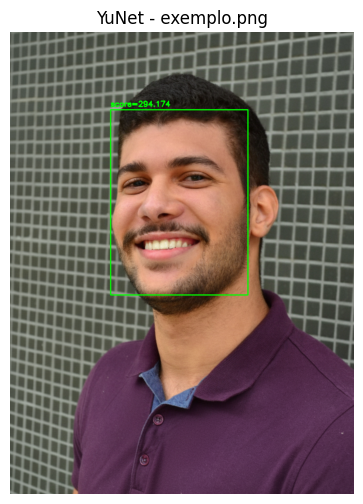

In [8]:
# Exemplo de uso do detector
test_img_path = TEST_DIR / "exemplo.png"

if test_img_path.exists():
    img = read_image(str(test_img_path))
    faces = detect_faces(img)
    print(f"Faces detectadas: {len(faces)}")
    draw_faces(img, faces, title=f"YuNet - {test_img_path.name}")
else:
    print(f"Coloque uma imagem em: {test_img_path}")

## 2) Identificação facial (SFace)

> Estratégia: criar uma base de embeddings por cliente e comparar por similaridade de cosseno.

### Formato sugerido da base `data/enroll/`
- `data/enroll/cliente_001/img1.jpg`
- `data/enroll/cliente_001/img2.jpg`
- `data/enroll/cliente_002/img1.jpg`

In [9]:
def get_face_embedding(img_bgr: np.ndarray):
    faces = detect_faces(img_bgr)
    if len(faces) == 0:
        return None, None
    face = faces[0].astype(np.float32)
    aligned = recognizer.alignCrop(img_bgr, face)
    feat = recognizer.feature(aligned)
    return feat, face

def cosine_similarity(f1, f2):
    # Match usa comparação de cosseno quando dis_type=0
    return float(recognizer.match(f1, f2, cv2.FaceRecognizerSF_FR_COSINE))

def build_gallery(enroll_root: Path):
    gallery = {}
    if not enroll_root.exists():
        return gallery

    for person_dir in sorted([p for p in enroll_root.iterdir() if p.is_dir()]):
        person_id = person_dir.name
        feats = []
        for img_path in person_dir.glob("*.jpg"):
            img = read_image(str(img_path))
            feat, face = get_face_embedding(img)
            if feat is not None:
                feats.append(feat)
        if feats:
            gallery[person_id] = feats
    return gallery

def identify_person(probe_img_bgr: np.ndarray, gallery: dict, threshold: float = 0.35):
    probe_feat, probe_face = get_face_embedding(probe_img_bgr)
    if probe_feat is None:
        return {"status": "NO_FACE", "best_id": None, "score": 0.0, "face": None}

    best_id = None
    best_score = -1.0

    for person_id, feat_list in gallery.items():
        scores = [cosine_similarity(probe_feat, f) for f in feat_list]
        person_score = max(scores) if scores else -1.0
        if person_score > best_score:
            best_score = person_score
            best_id = person_id

    status = "MATCH" if best_score >= threshold else "NO_MATCH"
    return {
        "status": status,
        "best_id": best_id,
        "score": float(best_score),
        "face": probe_face,
    }

In [10]:
# Construção da galeria e teste de identificação
gallery = build_gallery(ENROLL_DIR)
print(f"Clientes cadastrados: {len(gallery)} -> {list(gallery.keys())[:10]}")

probe_path = TEST_DIR / "probe.jpg"
if probe_path.exists() and gallery:
    probe = read_image(str(probe_path))
    result = identify_person(probe, gallery, threshold=0.35)
    print("Resultado identificação:", {k: v for k, v in result.items() if k != "face"})

    vis = probe.copy()
    if result["face"] is not None:
        x, y, w, h = map(int, result["face"][:4])
        color = (0, 255, 0) if result["status"] == "MATCH" else (0, 0, 255)
        text = f"{result['best_id']} | score={result['score']:.3f} | {result['status']}"
        cv2.rectangle(vis, (x, y), (x+w, y+h), color, 2)
        cv2.putText(vis, text, (x, max(20, y-8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Identificação facial")
    plt.show()
else:
    print(f"Garanta dados em {ENROLL_DIR} e uma imagem de teste em {probe_path}")

Clientes cadastrados: 2 -> ['cliente_001', 'cliente_002']
Garanta dados em /content/data/enroll e uma imagem de teste em /content/data/test/probe.jpg


In [11]:
from google.colab import files
import shutil

print("Escolha a foto para CADASTRO (será o cliente_teste):")
uploaded_enroll = files.upload()
for name in uploaded_enroll.keys():
    shutil.move(name, f'data/enroll/cliente_teste/{name}')
    print(f'Foto {name} salva no cadastro.')

print("\nEscolha a foto para TESTE (será comparada com o cadastro):")
uploaded_test = files.upload()
for name in uploaded_test.keys():
    shutil.move(name, 'data/test/probe.jpg')
    print(f'Foto salva como data/test/probe.jpg')

print("\n--- TUDO PRONTO! Agora você pode rodar as células de 'Identificação' e 'Decisão' abaixo. ---")

Escolha a foto para CADASTRO (será o cliente_teste):


Saving PERFIL_SEMCRACHA.png to PERFIL_SEMCRACHA.png
Foto PERFIL_SEMCRACHA.png salva no cadastro.

Escolha a foto para TESTE (será comparada com o cadastro):


Saving 3x4.JPEG to 3x4.JPEG
Foto salva como data/test/probe.jpg

--- TUDO PRONTO! Agora você pode rodar as células de 'Identificação' e 'Decisão' abaixo. ---


## 2.1) Cadastro de cliente via webcam

> Execute esta célula para **cadastrar um novo cliente**. Altere `CLIENTE_ID` e `N_FOTOS` conforme necessário.  
> Cada foto será salva em `data/enroll/{CLIENTE_ID}/imgN.jpg`.


📋 Cadastrando cliente: cliente_003
   Serão tiradas 3 fotos. Mude levemente a posição entre cada uma.

--- Foto 1/3 ---


<IPython.core.display.Javascript object>

📷 Foto salva em: /content/data/enroll/cliente_003/img1.jpg
✅ Face detectada (score=269.459)


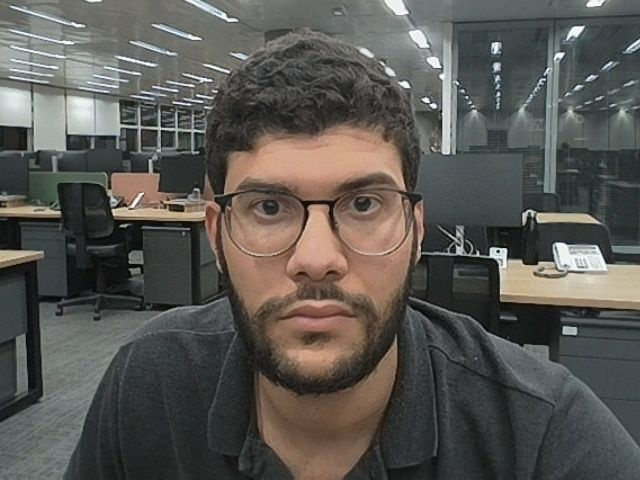

--- Foto 2/3 ---


<IPython.core.display.Javascript object>

📷 Foto salva em: /content/data/enroll/cliente_003/img2.jpg
✅ Face detectada (score=319.134)


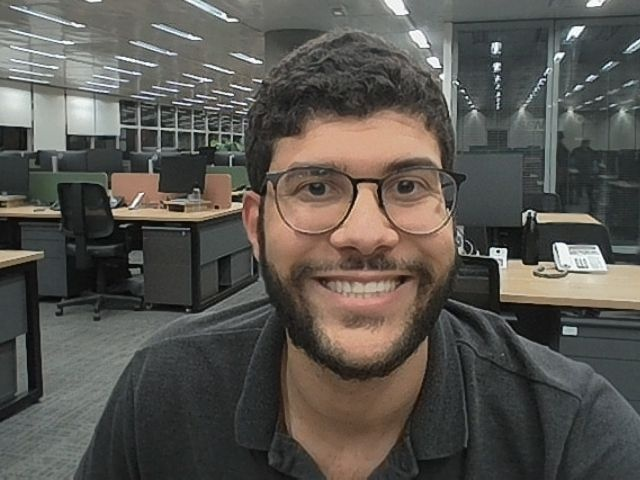

--- Foto 3/3 ---


<IPython.core.display.Javascript object>

📷 Foto salva em: /content/data/enroll/cliente_003/img3.jpg
✅ Face detectada (score=314.354)


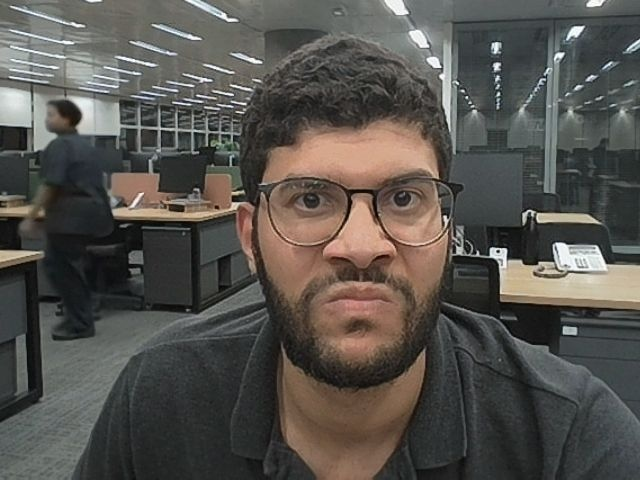


✅ Cadastro de 'cliente_003' concluído! 3 fotos em: /content/data/enroll/cliente_003


In [13]:

# ============================================================
# Cadastro de cliente via webcam
# ============================================================
from IPython.display import Image as ColabImage

# ← Altere aqui antes de rodar
CLIENTE_ID = "cliente_003"
N_FOTOS = 3  # número de fotos para o cadastro (recomendado: 3 a 5)

enroll_dir_cliente = ENROLL_DIR / CLIENTE_ID
enroll_dir_cliente.mkdir(parents=True, exist_ok=True)
TEST_DIR.mkdir(parents=True, exist_ok=True)

print(f"📋 Cadastrando cliente: {CLIENTE_ID}")
print(f"   Serão tiradas {N_FOTOS} fotos. Mude levemente a posição entre cada uma.\n")

for i in range(1, N_FOTOS + 1):
    print(f"--- Foto {i}/{N_FOTOS} ---")
    path = take_photo(str(enroll_dir_cliente / f"img{i}.jpg"))
    img = cv2.imread(path)
    faces = detect_faces(img)
    if len(faces) == 0:
        print(f"⚠️  Nenhuma face detectada na foto {i}. Tente novamente com melhor iluminação.")
    else:
        print(f"✅ Face detectada (score={float(faces[0][4]):.3f})")
    display.display(ColabImage(path, width=300))

print(f"\n✅ Cadastro de '{CLIENTE_ID}' concluído! {N_FOTOS} fotos em: {enroll_dir_cliente}")


## 3) Detecção de vivacidade (liveness)

> Para bloquear foto estática, usar **desafio ativo** com sequência curta de frames (ex.: piscar + movimento lateral leve da cabeça).

> Abaixo há um baseline com EAR (Eye Aspect Ratio) usando FaceMesh.

In [19]:
# Índices dos olhos no MediaPipe FaceMesh
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

def euclid(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

def eye_aspect_ratio(eye_pts):
    # EAR = (||p2-p6|| + ||p3-p5||) / (2*||p1-p4||)
    p1, p2, p3, p4, p5, p6 = eye_pts
    return (euclid(p2, p6) + euclid(p3, p5)) / (2.0 * euclid(p1, p4) + 1e-8)

def extract_eye_points(landmarks, eye_idx, w, h):
    pts = []
    for idx in eye_idx:
        lm = landmarks[idx]
        pts.append((lm.x * w, lm.y * h))
    return pts

def liveness_blink_from_frames(frames_bgr, ear_threshold=0.20, min_blinks=1):
    import mediapipe as mp
    mp_face_mesh = mp.solutions.face_mesh
    blink_count = 0
    was_closed = False
    ear_values = []

    with mp_face_mesh.FaceMesh(
        static_image_mode=False, max_num_faces=1, refine_landmarks=True,
        min_detection_confidence=0.5, min_tracking_confidence=0.5
    ) as face_mesh:

        for frame in frames_bgr:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = face_mesh.process(rgb)
            if not res.multi_face_landmarks:
                continue

            h, w = frame.shape[:2]
            lm = res.multi_face_landmarks[0].landmark

            left_eye = extract_eye_points(lm, LEFT_EYE, w, h)
            right_eye = extract_eye_points(lm, RIGHT_EYE, w, h)

            ear_l = eye_aspect_ratio(left_eye)
            ear_r = eye_aspect_ratio(right_eye)
            ear = (ear_l + ear_r) / 2.0
            ear_values.append(float(ear))

            if ear < ear_threshold and not was_closed:
                was_closed = True
            elif ear >= ear_threshold and was_closed:
                blink_count += 1
                was_closed = False

    is_live = blink_count >= min_blinks
    return {
        "is_live": bool(is_live),
        "blink_count": int(blink_count),
        "ear_mean": float(np.mean(ear_values)) if ear_values else 0.0,
        "ear_min": float(np.min(ear_values)) if ear_values else 0.0,
    }

In [ ]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# ============================================================
# Funções de decisão e evidência
# ============================================================

def save_evidence(probe_img_bgr, decision_payload: dict, prefix: str = "tentativa"):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    img_path = EVIDENCE_DIR / f"{prefix}_{ts}.jpg"
    meta_path = EVIDENCE_DIR / f"{prefix}_{ts}.json"
    cv2.imwrite(str(img_path), probe_img_bgr)
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(decision_payload, f, ensure_ascii=False, indent=2)
    return str(img_path), str(meta_path)

def auth_decision(probe_img_bgr, gallery, liveness_result, id_threshold=0.35):
    id_result = identify_person(probe_img_bgr, gallery, threshold=id_threshold)
    approved = (id_result["status"] == "MATCH") and liveness_result.get("is_live", False)

    payload = {
        "timestamp": datetime.now().isoformat(),
        "decision": "APROVADO" if approved else "EM_REVISAO",
        "reason": "Identidade confirmada e liveness aprovado." if approved
                  else "Falha na identificação ou na vivacidade.",
        "identificacao": {
            "status": id_result["status"],
            "best_id": id_result["best_id"],
            "score": id_result["score"],
            "threshold": id_threshold,
        },
        "liveness": liveness_result,
    }
    return payload

# ============================================================
# Fluxo completo de autenticação com webcam real
# ============================================================

# Ajuste para garantir que arquivos PNG também sejam lidos na galeria
def build_gallery_v2(enroll_root):
    gallery = {}
    valid_extensions = ['*.jpg', '*.jpeg', '*.png', '*.PNG', '*.JPG']
    for person_dir in sorted([p for p in enroll_root.iterdir() if p.is_dir()]):
        person_id = person_dir.name
        feats = []
        for ext in valid_extensions:
            for img_path in person_dir.glob(ext):
                img = cv2.imread(str(img_path))
                if img is not None:
                    feat, _ = get_face_embedding(img)
                    if feat is not None: feats.append(feat)
        if feats: gallery[person_id] = feats
    return gallery

gallery = build_gallery_v2(ENROLL_DIR)
print(f"Clientes na galeria: {list(gallery.keys())}")

if not gallery:
    print("\n⚠️ Galeria vazia! Verifique se as imagens estão na pasta data/enroll/")
else:
    print("\n📷 PASSO 1/2 — Captura para IDENTIFICAÇÃO")
    probe_path_webcam = str(TEST_DIR / "probe.jpg")
    try:
        take_photo(probe_path_webcam)
        probe = read_image(probe_path_webcam)

        print("\n👁 PASSO 2/2 — Captura para LIVENESS")
        frames_liveness = capture_frames(n_frames=20, interval_ms=150)

        if not frames_liveness:
            print("⚠️ Nenhum frame capturado.")
        else:
            live_result = liveness_blink_from_frames(frames_liveness, ear_threshold=0.20, min_blinks=1)
            decision_payload = auth_decision(probe, gallery, live_result, id_threshold=0.35)

            print("\n" + "=" * 55)
            print(json.dumps(decision_payload, ensure_ascii=False, indent=2))
            print("=" * 55)

            vis = probe.copy()
            id_res = decision_payload["identificacao"]
            face_result = identify_person(probe, gallery)
            if face_result["face" ] is not None:
                x, y, w, h = map(int, face_result["face"][:4])
                color = (0, 255, 0) if decision_payload["decision"] == "APROVADO" else (0, 0, 255)
                label = f"{id_res['best_id']} | score={id_res['score']:.3f}"
                cv2.rectangle(vis, (x, y), (x+w, y+h), color, 2)
                cv2.putText(vis, label, (x, max(20, y-8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

            plt.figure(figsize=(8, 6))
            plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.show()

            save_evidence(probe, decision_payload, prefix="auth_webcam")
    except Exception as e:
        print(f"Erro no processamento: {e}")

Clientes na galeria: ['cliente_001', 'cliente_002', 'cliente_003']

📷 PASSO 1/2 — Captura para IDENTIFICAÇÃO


<IPython.core.display.Javascript object>

## 4) Ajuste de limiares e governança (essencial para produção)

> Use uma base de validação separada e ajuste os limiares para equilibrar segurança e fricção.

- `threshold_identificacao`: aumente para reduzir falso aceite (fraude), diminua para reduzir falso bloqueio.
- `ear_threshold` e `min_blinks`: calibrar por câmera/dispositivo e perfil de usuário.
- Logar tentativas em `evidencias/` para auditoria, explicabilidade e retreino.
- Em serviços críticos (ex.: crédito), exigir **2 fatores**: senha + face + liveness ativo.

### Próximo passo recomendado
1. Testar com no mínimo 30 clientes reais (com consentimento).
2. Medir FAR/FRR e EER.
3. Definir limiar operacional por risco do produto (crédito > transferência > consulta).